In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import simpy
from tqdm import tqdm

# Analysing the Results of DES Simulations

In this example, we use the **simulation of a gate reader at an airport**, which we have already introduced in the document `09_01_gate_1.ipynb`. In the following, we address two key questions:

1. How can transient distributions be visualized, and how can we distinguish between the warm-up phase and the steady-state in DES simulation results?  
2. What is the impact of initial conditions on the warm-up phase?  

To answer these questions, this notebook is structured into three steps:

- **Step 1:** Set up the DES simulation of a gate reader at an airport (using the same simulation as in `09_01_gate_1.ipynb`).  

- **Step 2:** Analyze the simulation results with respect to the warm-up phase and the steady-state phase.  

- **Step 3:** Investigate the impact of initial conditions on the warm-up phase using an illustrative example.  


## Step 1: DES Simulation of Gate Reader

We perform the same simulation as in the document `09_01_gate_1.ipynb`. Therefore, we adopt the model parameterization from that document, in particular `mean_interarrival_time`, `mean_service_time`, and `number_of_servers`. In addition, we use the same arrival and service processes as defined in the original simulation.

In [4]:
# Get parametrisation from document 09_01_gate_1.ipynb

mean_interarrival_time = 5.1    # Seconds
mean_service_time = 4.8         # Seconds
number_of_servers = 1           # Number of Servers

In [5]:
### Service Process ###

# Define the mean service rate, use variable name `mean_service_rate`
mean_service_rate = 1/mean_service_time

# Function to generate service times (Service Process)
def generate_service_time(mean_service_rate):
    """Generate service time based on exponential distribution."""
    return random.expovariate(mean_service_rate)

In [6]:
### Arrival Process ###
# Define the mean arrival rate, use variable name `mean_arrival_rate`
mean_arrival_rate = 1 / mean_interarrival_time

# Function to generate interarrival times (Arrival Process)
def generate_interarrival_time(mean_arrival_rate):
    """Generate interarrival time based on exponential distribution."""
    return random.expovariate(mean_arrival_rate)

In [7]:
# Simulation parameters
C = 1                   # Number of Servers
ARRIVAL_RATE = mean_arrival_rate  # Lambda: Average number of arrivals per time unit
SERVICE_RATE = mean_service_rate  # Mu: Average number of services per server per time unit
SIM_TIME = 5 * 3600         # Total simulation time
NUM_RUNS = 2000             # Number of independent simulation runs
CUSTOMER_INTERVAL = 5      # Record delays for every 20th customer


# Function to generate interarrival times
def generate_interarrival_time(arrival_rate):
    """Generate interarrival time based on exponential distribution."""
    return random.expovariate(arrival_rate)

# Function to generate service times
def generate_service_time(mean_service_rate):
    """Generate service time based on exponential distribution."""
    return random.expovariate(mean_service_rate)

# Simulation function
def simulate_one_run(customer_interval):
    """Simulate a single M/M/c run and record delays & queue lengths for every `customer_interval` customer."""
    delays = {}
    queue_lengths = {}

    def customer(env, name, server, service_rate):
        """A customer process arriving and waiting for service."""
        arrival_time = env.now

        # Log queue length at arrival
        queue_length_at_arrival = len(server.queue)

        with server.request() as request:
            yield request  # Wait for the server
            wait_time = env.now - arrival_time  # Time spent in queue
            
            if name % customer_interval == 0:  # Record for every `customer_interval` customer
                delays[name] = wait_time
                queue_lengths[name] = queue_length_at_arrival
            
            service_time = generate_service_time(service_rate)
            yield env.timeout(service_time)  # Simulate service

    def arrival_process(env, server, arrival_rate, service_rate):
        """Process generating customers according to a Poisson arrival process."""
        customer_id = 0
        while True:
            interarrival_time = generate_interarrival_time(arrival_rate)
            yield env.timeout(interarrival_time)
            customer_id += 1
            env.process(customer(env, customer_id, server, service_rate))

    # Create the simulation environment
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=C)
    env.process(arrival_process(env, server, ARRIVAL_RATE, SERVICE_RATE))
    env.run(until=SIM_TIME)

    return delays, queue_lengths

# Run the simulation NUM_RUNS times and collect data
all_delays = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}
all_queue_lengths = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}

for run in tqdm(range(NUM_RUNS), desc="Running Simulations", unit="run"):
    delays, queue_lengths = simulate_one_run(CUSTOMER_INTERVAL)

    for customer, delay in delays.items():
        if customer in all_delays:
            all_delays[customer].append(delay)
    
    for customer, queue_length in queue_lengths.items():
        if customer in all_queue_lengths:
            all_queue_lengths[customer].append(queue_length)

# Convert results to DataFrames for analysis
df_delays = pd.DataFrame.from_dict(all_delays, orient="index").T
df_queue_lengths = pd.DataFrame.from_dict(all_queue_lengths, orient="index").T


Running Simulations: 100%|██████████| 2000/2000 [00:26<00:00, 75.25run/s]


## Step 2: Warm-up vs. Steady State

During the warm-up phase, the transient distribution of the simulation results changes over time, whereas in the steady state, the transient distribution remains stable.  

To identify when the system reaches steady state, we proceed in two steps. First, we visualize the simulation results. In this example, we focus exclusively on the delay experienced by passengers in the queue.  

Second, we inspect the resulting plot to determine when:
- (i) the mean of the simulation results stabilizes, and  
- (ii) the distribution of the results becomes stable, as illustrated by the 25–75th percentiles and the 10–90th percentiles.  

The region in which both the mean and the distribution remain approximately constant can be considered the **steady-state phase**, while the preceding period corresponds to the **warm-up phase**.

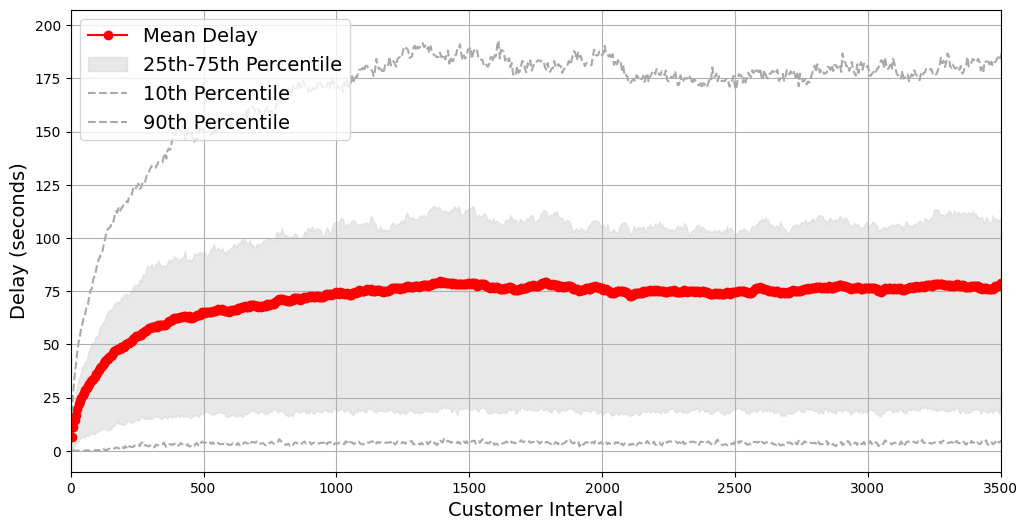

In [8]:
mean_delays = df_delays.mean(axis=0)  # Mean delay per customer interval
percentiles = df_delays.quantile([0.10, 0.25, 0.75, 0.90], axis=0)  # Compute percentiles

# Extract percentile values
customer_intervals = mean_delays.index
p10 = percentiles.loc[0.10]
p25 = percentiles.loc[0.25]
p75 = percentiles.loc[0.75]
p90 = percentiles.loc[0.90]


plt.figure(figsize=(12, 6))
plt.plot(customer_intervals, mean_delays, color='r', label="Mean Delay", marker='o')
plt.fill_between(customer_intervals, p25, p75, color='lightgrey', alpha=0.5, label="25th-75th Percentile")
plt.plot(customer_intervals, p10, label="10th Percentile", linestyle='--', color='darkgrey')
plt.plot(customer_intervals, p90, label="90th Percentile", linestyle='--', color='darkgrey')
plt.xlabel("Customer Interval", fontsize=14)
plt.ylabel("Delay (seconds)", fontsize=14)
plt.xlim((0, 3500))
plt.legend(fontsize=14)
plt.grid()

## Step 3: Influence of Initial Conditions on the Warm-up Phase

The initial conditions of a simulation model (e.g., the number of passengers in the queue or being served at the start of the simulation) influence both the evolution and the duration of the warm-up phase.  

To illustrate this effect, we consider four different simulation scenarios. These scenarios differ only in the number of passengers (`INITIAL_ENTITIES`) that are already present in the queue at the gate at the start of the simulation. Each scenario is simulated 1,500 times (`NUM_RUNS`) over a time horizon of `4 * 3600` seconds.  

After running all scenarios, we plot the average waiting time experienced by passengers in the queue (averaged over the 1,500 simulation runs) as a function of the customer index. This allows us to visualize how `INITIAL_ENTITIES` (i.e., the initial conditions) affect the warm-up phase.  

It should be noted that the simulation results of the four scenarios differ only during the warm-up phase. The steady-state behavior is identical across all scenarios.

In [9]:
# Parametrization of Simulation Model
C = 1                                              # Number of Servers
ARRIVAL_RATE = mean_arrival_rate            # Lambda: Average number of arrivals per time unit
SERVICE_RATE = mean_service_rate            # Mu: Average number of services per server per time unit
SIM_TIME = 4 * 3600                                # Total simulation time
NUM_RUNS = 1500                                    # Number of independent simulation runs
CUSTOMER_INTERVAL = 5                              # Record delays for every 5th customer
INITIAL_ENTITIES = [0, 10, 20, 30]      # Different initial queue lengths


# Simulation function
def simulate_one_run(initial_queue, customer_interval):
    """Simulate a single M/M/c run with an initial queue."""
    delays = {}
    queue_lengths = {}

    def initial_queue_process(env, server, initial_queue, service_rate):
        """Populate the system with `initial_queue` customers at the start."""
        for i in range(initial_queue):
            env.process(customer(env, f"Initial-{i}", server, service_rate))
            yield env.timeout(0)  # Ensure proper scheduling

    def customer(env, name, server, service_rate):
        """A customer process arriving and waiting for service."""
        arrival_time = env.now
        queue_length_at_arrival = len(server.queue)  # Log queue length

        with server.request() as request:
            yield request  # Wait for the server
            wait_time = env.now - arrival_time  # Time spent in queue
            
            if isinstance(name, int) and name % customer_interval == 0:  # Record every `customer_interval` customer
                delays[name] = wait_time
                queue_lengths[name] = queue_length_at_arrival
            
            service_time = generate_service_time(service_rate)
            yield env.timeout(service_time)  # Simulate service

    def arrival_process(env, server, arrival_rate, service_rate):
        """Process generating customers according to a Poisson arrival process."""
        customer_id = 0
        while True:
            interarrival_time = generate_interarrival_time(arrival_rate)
            yield env.timeout(interarrival_time)
            customer_id += 1
            env.process(customer(env, customer_id, server, service_rate))

    # Create the simulation environment
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=C)

    # Populate initial queue
    env.process(initial_queue_process(env, server, initial_queue, SERVICE_RATE))
    
    # Start arrival process
    env.process(arrival_process(env, server, ARRIVAL_RATE, SERVICE_RATE))
    env.run(until=SIM_TIME)

    return delays, queue_lengths

# Run the simulation for different initial queue conditions
results = {}
for initial_queue in INITIAL_ENTITIES:
    all_delays = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}
    all_queue_lengths = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}

    # Run simulations with tqdm progress bar
    for _ in tqdm(range(NUM_RUNS), desc=f"Simulating for Initial Queue = {initial_queue}", unit="run"):
        delays, queue_lengths = simulate_one_run(initial_queue, CUSTOMER_INTERVAL)

        for customer, delay in delays.items():
            if customer in all_delays:
                all_delays[customer].append(delay)

        for customer, queue_length in queue_lengths.items():
            if customer in all_queue_lengths:
                all_queue_lengths[customer].append(queue_length)

    results[initial_queue] = (all_delays, all_queue_lengths)

# Convert results to DataFrames for each initial queue condition
converted_results = {}  # Create a new dictionary to store the converted DataFrames

for initial_queue, (delays, queue_lengths) in results.items():
    df_delays = pd.DataFrame.from_dict(delays, orient="index").T
    df_queue_lengths = pd.DataFrame.from_dict(queue_lengths, orient="index").T
    converted_results[initial_queue] = (df_delays, df_queue_lengths)

# If you want to overwrite the original dictionary with the converted DataFrames
results = converted_results

Simulating for Initial Queue = 30: 100%|██████████| 1500/1500 [00:16<00:00, 90.07run/s]


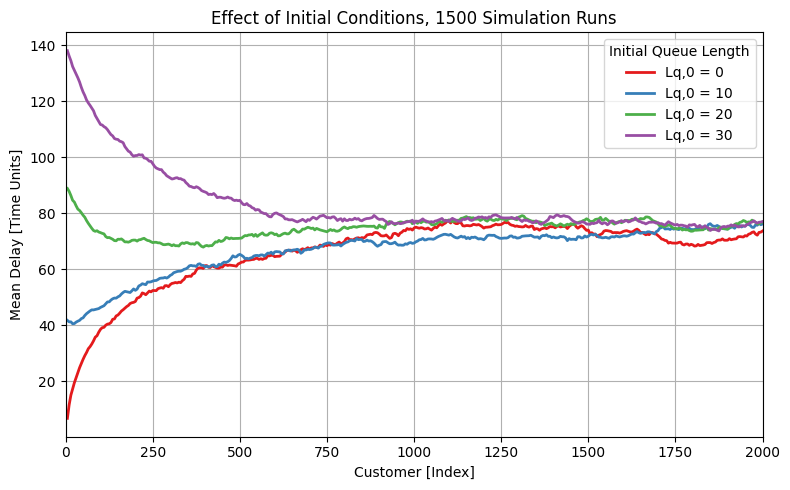

In [11]:
# Define max. Index for Plot
idx_max = 2000

# Use a Matplotlib colormap
colors = plt.cm.Set1.colors

plt.figure(figsize=(8, 5))

# Loop through each initial queue length and plot mean delay
for i, initial_queue in enumerate(INITIAL_ENTITIES):
    df_delays, _ = results[initial_queue]   # Extract delay DataFrame
    mean_delays = df_delays.mean(axis=0)         # Compute mean delay per interval

    # Filter customer indices <= idx_max
    mean_delays = mean_delays.loc[mean_delays.index <= idx_max]

    # Plot line
    plt.plot(
        mean_delays.index,
        mean_delays.values,
        label=f"Lq,0 = {initial_queue}",
        color=colors[i % len(colors)],
        linewidth=2
    )

# Labels and title
plt.title(f"Effect of Initial Conditions, {NUM_RUNS} Simulation Runs")
plt.xlabel("Customer [Index]")
plt.ylabel("Mean Delay [Time Units]")
plt.legend(title="Initial Queue Length")
plt.grid()
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()